UTS Data Science

*   Nama : Novika Ardiyaningtyas
*   NIM : 250401020135
*   Kelas: IF401

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')

# Load Dataset
df = sns.load_dataset('tips')

print('Shape Dataset:', df.shape)
print('\nTipe Kolom:')
print(df.dtypes)
print('\nStatistik Deskriptif:')
print(df.describe().round(2))
print('\nMissing Values:')
print(df.isnull().sum())
print('\nJumlah data per Hari:')
print(df['day'].value_counts())
print('\nJumlah data per Waktu Makan:')
print(df['time'].value_counts())

Shape Dataset: (244, 7)

Tipe Kolom:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Statistik Deskriptif:
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00

Missing Values:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Jumlah data per Hari:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

Jumlah data per Waktu Makan:
time
Dinner    176
Lunch      68
Name: count, dtype: int64


Hasil eksplorasi awal dataset Tips menunjukkan struktur dan fitur data transaksi restoran. Hasil pemeriksaan menunjukkan bahwa dataset tidak memiliki nilai yang tidak ada, yang berarti kualitas data cukup baik untuk analisis lebih lanjut. Statistik deskriptif menunjukkan sebaran nilai pada variabel numerik seperti total_bill, tip, dan ukuran. Selain itu, data yang didistribusikan berdasarkan hari dan waktu makan menunjukkan bahwa jumlah transaksi lebih banyak terjadi pada hari tertentu dan didominasi oleh waktu makan malam, atau makan malam.

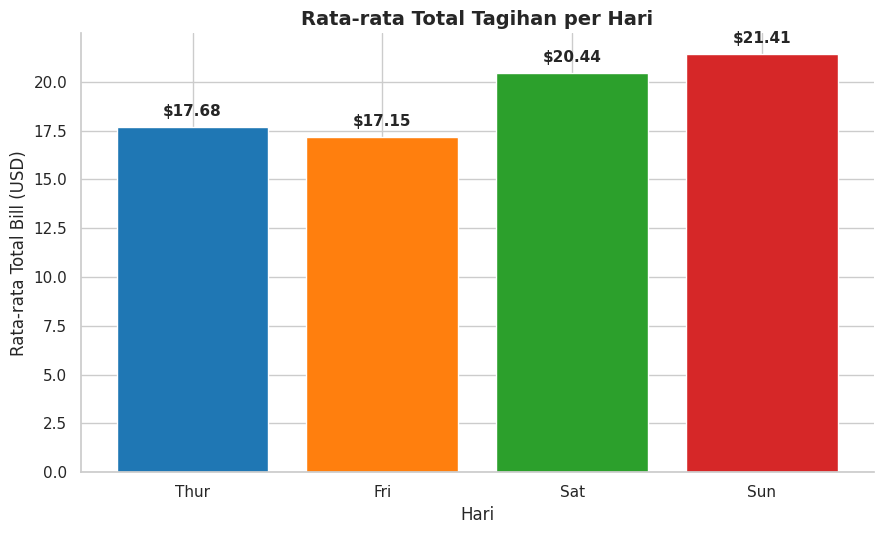

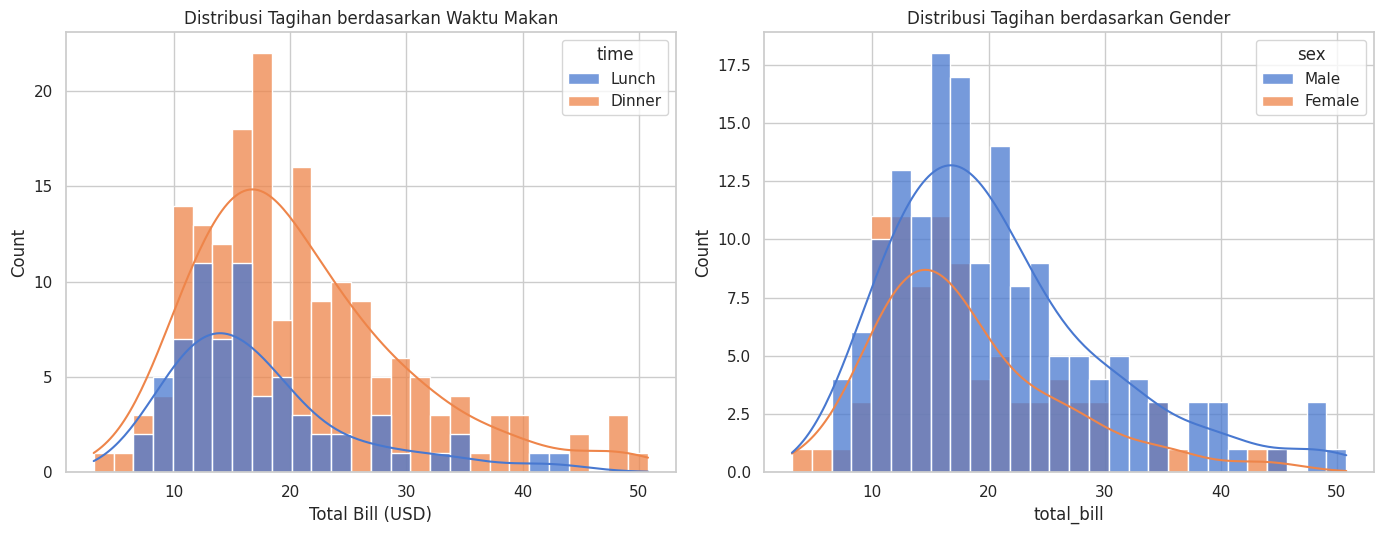

In [2]:
urutan_hari = ['Thur', 'Fri', 'Sat', 'Sun']

# Grafik 1: Bar Chart
fig, ax = plt.subplots(figsize=(9, 5.5))
avg_bill = df.groupby('day', observed=True)['total_bill'].mean().reindex(urutan_hari)
bars = ax.bar(avg_bill.index, avg_bill.values,
              color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], edgecolor='white')
ax.bar_label(bars, fmt='$%.2f', padding=6, fontsize=11, fontweight='bold')
ax.set_title('Rata-rata Total Tagihan per Hari', fontsize=14, fontweight='bold')
ax.set_xlabel('Hari')
ax.set_ylabel('Rata-rata Total Bill (USD)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('grafik1_bar_novika.png', dpi=200, bbox_inches='tight')
plt.show()

# Grafik 2: Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.histplot(data=df, x='total_bill', hue='time', kde=True, bins=28, alpha=0.75, ax=axes[0])
axes[0].set_title('Distribusi Tagihan berdasarkan Waktu Makan')
axes[0].set_xlabel('Total Bill (USD)')

sns.histplot(data=df, x='total_bill', hue='sex', kde=True, bins=28, alpha=0.75, ax=axes[1])
axes[1].set_title('Distribusi Tagihan berdasarkan Gender')
plt.tight_layout()
plt.savefig('grafik2_hist_novika.png', dpi=200, bbox_inches='tight')
plt.show()

Minggu dan Sabtu memiliki tagihan total rata-rata tertinggi, sedangkan Kamis dan Jumat memiliki tagihan rata-rata yang lebih rendah, menurut visualisasi data. Selain itu, distribusi tagihan menunjukkan bahwa transaksi untuk makan malam lebih banyak dan bervariasi dibandingkan dengan makan siang. Selain itu, visualisasi ini membantu memahami pola transaksi pelanggan berdasarkan hari, waktu makan, dan gender karena pola distribusi tagihan antara pelanggan laki-laki dan perempuan relatif serupa, sehingga perbedaan gender tidak memengaruhi besarnya total tagihan.

/tmp/ipykernel_1216/2974261027.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='day', y='total_bill', order=urutan_hari,


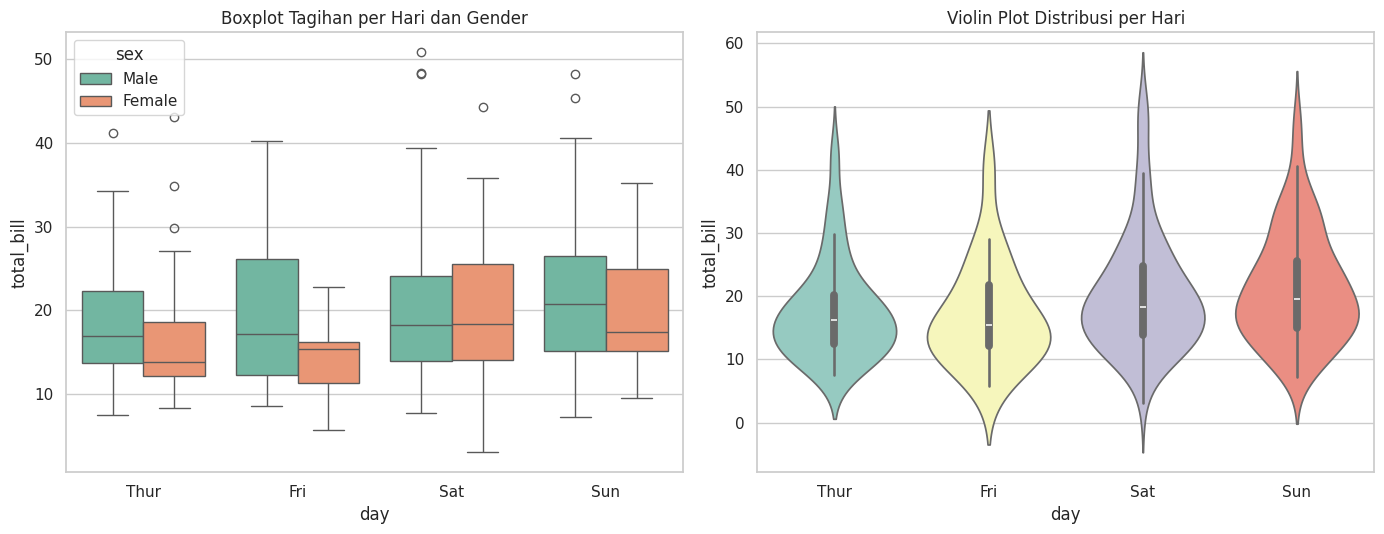

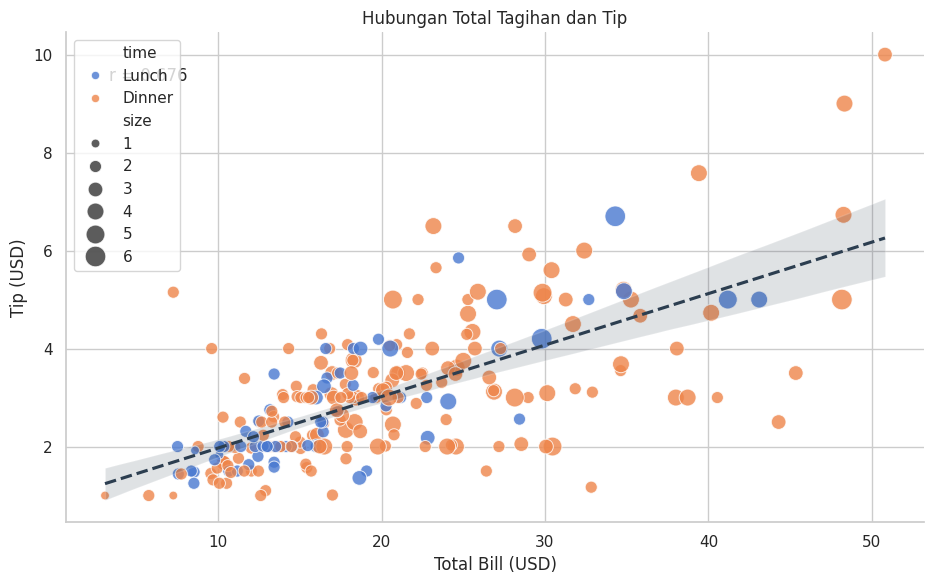

In [3]:
# Grafik 3: Boxplot & Violin
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.boxplot(data=df, x='day', y='total_bill', hue='sex',
            order=urutan_hari, palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Tagihan per Hari dan Gender')

sns.violinplot(data=df, x='day', y='total_bill', order=urutan_hari,
               palette='Set3', ax=axes[1])
axes[1].set_title('Violin Plot Distribusi per Hari')
plt.tight_layout()
plt.savefig('grafik3_box_novika.png', dpi=200, bbox_inches='tight')
plt.show()

# Grafik 4: Scatter Plot
fig, ax = plt.subplots(figsize=(9.5, 6))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time',
                size='size', sizes=(40, 220), alpha=0.8, ax=ax)
sns.regplot(data=df, x='total_bill', y='tip', scatter=False,
            color='#2c3e50', line_kws={'linestyle':'--'}, ax=ax)

r, p = stats.pearsonr(df['total_bill'], df['tip'])
ax.text(0.05, 0.9, f'r = {r:.3f}', transform=ax.transAxes,
        fontsize=12, bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

ax.set_title('Hubungan Total Tagihan dan Tip')
ax.set_xlabel('Total Bill (USD)')
ax.set_ylabel('Tip (USD)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('grafik4_scatter_novika.png', dpi=200, bbox_inches='tight')
plt.show()

Menurut boxplot dan violin plot, nilai total tagihan cenderung lebih tinggi pada akhir pekan, terutama hari Sabtu dan Minggu. Ini karena sebaran data pada hari-hari ini lebih luas dibandingkan hari lainnya, yang menunjukkan variasi tagihan yang lebih besar. Tidak terlihat ada perbedaan yang signifikan antara pelanggan laki-laki dan perempuan dalam hal tagihan. Scatter plot menunjukkan hubungan positif antara total tagihan dan jumlah tip yang diberikan; lebih besar total tagihan, lebih besar kemungkinan tip yang diberikan pelanggan. Nilai korelasi Pearson yang positif memperkuat hubungan ini, sehingga total tagihan dapat digunakan sebagai alat yang cukup baik untuk memprediksi besarnya tip.

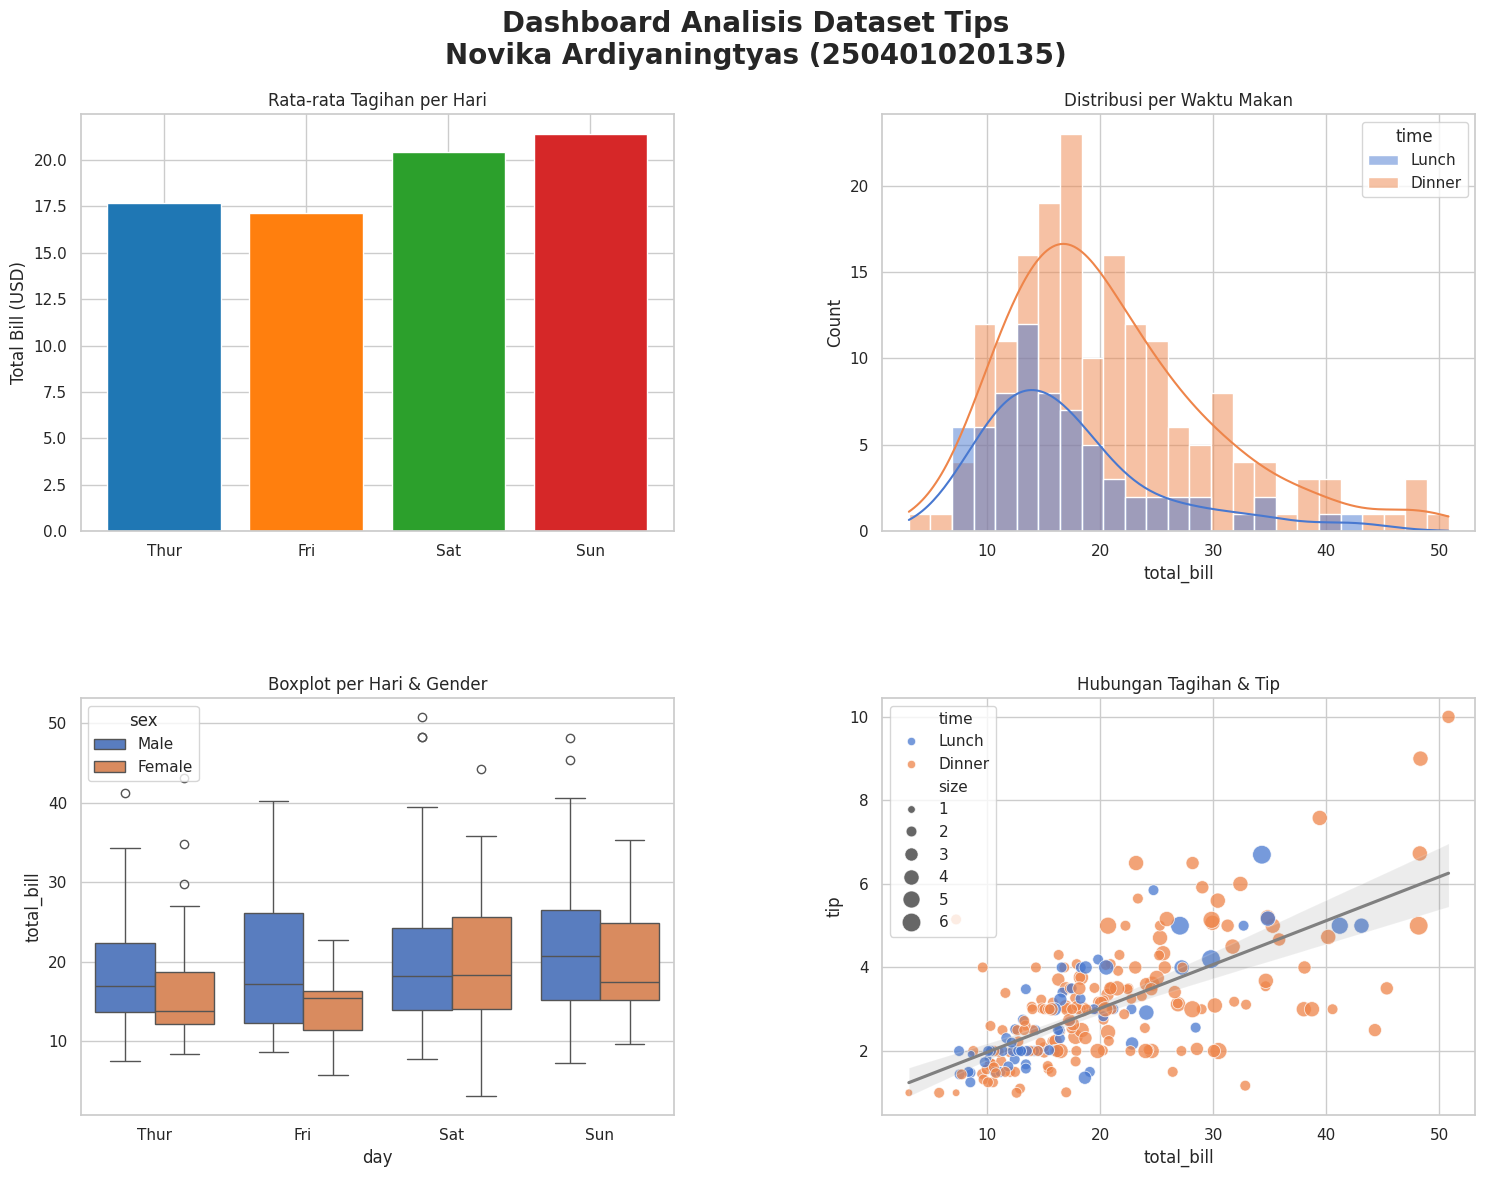

✅ Dashboard lengkap berhasil disimpan!


In [4]:
fig = plt.figure(figsize=(18, 13))
fig.suptitle('Dashboard Analisis Dataset Tips\nNovika Ardiyaningtyas (250401020135)',
             fontsize=20, fontweight='bold', y=0.96)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Grafik 1 di ax1
avg_bill = df.groupby('day', observed=True)['total_bill'].mean().reindex(urutan_hari)
ax1.bar(avg_bill.index, avg_bill.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], edgecolor='white')
ax1.set_title('Rata-rata Tagihan per Hari')
ax1.set_ylabel('Total Bill (USD)')

# Grafik 2 di ax2
sns.histplot(data=df, x='total_bill', hue='time', kde=True, bins=25, ax=ax2)
ax2.set_title('Distribusi per Waktu Makan')

# Grafik 3 di ax3
sns.boxplot(data=df, x='day', y='total_bill', hue='sex', order=urutan_hari, ax=ax3)
ax3.set_title('Boxplot per Hari & Gender')

# Grafik 4 di ax4
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', size='size',
                sizes=(30,180), alpha=0.75, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip', scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip')

plt.savefig('dashboard_tips_novika_final.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Dashboard lengkap berhasil disimpan!')

Dashboard analisis dataset Tips menunjukkan bahwa akhir pekan terutama hari Minggu dan Sabtu memiliki total tagihan tertinggi. Menurut distribusi tagihan, transaksi makan malam lebih banyak dan bervariasi dibandingkan dengan makan siang. Selain itu, ada korelasi positif antara jumlah tip yang diberikan pelanggan dan total tagihan. Secara keseluruhan, visualisasi dashboard membuat lebih mudah untuk memahami pola transaksi pelanggan berdasarkan hari, waktu makan, gender, dan jumlah tip yang diberikan.

Kesimpulan: Dalam praktikum ini, teknik eksplorasi data, statistik deskriptif, visualisasi data, dan interpretasi hubungan antarvariabel dipelajari dengan menggunakan Python, Pandas, Matplotlib, dan Seaborn. Hasil analisis menunjukkan bahwa visualisasi data sangat membantu dalam pemahaman yang lebih baik tentang pola, tren, dan karakteristik data.